#Introduction

### The Influence of Missing Data on Model Performance

In this experiment, the effect of missing data on machine learning model performance is investigated.

The Logistic Regression model is trained on datasets containing different amounts of missing values. The objective is to determine how increasing the proportion of missing data influences the predictive performance of the model.

All missing values are handled using median imputation to simulate a common preprocessing technique used in real-world machine learning projects.

##Import Libraries

The required libraries are imported for data processing, model training, and evaluation

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,precision_score, recall_score,f1_score)

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

## Load Dataset

The Titanic dataset is loaded for the experiment.

In [18]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Preparation
Before introducing missing values, the dataset is preprocessed.

Categorical variables are converted into numerical values using one-hot encoding, and unnecessary columns are removed.

The Age column is intentionally left unchanged because missing values will be introduced and handled during the experiment.

In [19]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = pd.get_dummies(df,columns=["Sex", "Embarked"],drop_first=True)

df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

## Creating the Experiment Function

To avoid repeating the same code several times, a function is created.

The function automatically:

- creates a copy of the dataset;
- introduces a selected percentage of missing values;
- fills missing values using the median;
- encodes categorical variables;
- splits the dataset;
- trains a Logistic Regression model;
- calculates the evaluation metrics.

This approach ensures that every experiment is performed under identical conditions.

In [23]:
def evaluate_missing_data(df, missing_fraction):

    data = df.copy()

    missing_indexes = data.sample(frac=missing_fraction,random_state=42).index

    data.loc[missing_indexes, "Age"] = np.nan

    data["Age"] = data["Age"].fillna(data["Age"].median())

    X = data.drop(columns=["Survived"])
    y = data["Survived"]

    X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

    model = LogisticRegression( max_iter=1000,random_state=42)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test,y_pred).ravel()

    return {"Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp}

## Running Experiments

The experiment is performed with different levels of missing data.

Four datasets are evaluated:

- Original dataset (0% missing data)
- Dataset with 10% missing values
- Dataset with 20% missing values
- Dataset with 30% missing values

This allows analyzing how increasing the amount of missing data affects machine learning performance.

In [24]:
results = []

missing_levels = [0, 0.1, 0.2, 0.3]

for level in missing_levels:

    result = evaluate_missing_data(df, level)

    result["Missing Data"] = f"{int(level * 100)}%"

    results.append(result)

## Results Comparison

The results from all experiments are combined into a single table to compare the influence of different levels of missing data.

In [16]:
comparison = pd.DataFrame(results)

comparison = comparison[[ "Missing Data", "Accuracy", "Precision","Recall","F1-score","True Negative","False Positive","False Negative","True Positive"]]

comparison = comparison.round(3)

comparison

,Missing Data,Accuracy,Precision,Recall,F1-score,True Negative,False Positive,False Negative,True Positive
0,0%,0.810,0.786,0.743,0.764,90,15,19,55
1,10%,0.777,0.730,0.730,0.730,85,20,20,54
2,20%,0.765,0.705,0.743,0.724,82,23,19,55
3,30%,0.765,0.705,0.743,0.724,82,23,19,55


##Analysis of Results

The experiment shows that increasing the amount of missing data generally reduces the performance of the Logistic Regression model.

With 0% missing data, the model achieved the highest Accuracy of 0.810, with Precision of 0.786, Recall of 0.743, and an F1-score of 0.764.

When 10% of the Age values were made missing, Accuracy decreased to 0.777. Precision and Recall also decreased to 0.730, resulting in an F1-score of 0.730.

At 20% missing data, Accuracy decreased further to 0.765. Precision dropped to 0.705, while Recall increased slightly to 0.743. The F1-score was 0.724.

At 30% missing data, Accuracy remained at 0.765. Precision remained at 0.705, Recall was 0.743, and the F1-score remained at 0.724.

This shows that the largest decrease in Accuracy occurred between 0% and 10% missing data. After 20%, the Accuracy stabilized at 0.765, indicating that the model's performance did not continue to decrease between 20% and 30% missing data.

Overall, missing data negatively affected the Logistic Regression model, particularly its Accuracy, Precision, and F1-score. However, Recall remained relatively stable at higher levels of missing data.

## Conclusion

In this experiment, the influence of missing data on Logistic Regression performance was investigated using the Titanic dataset.

The results show that the model performed best with 0% missing data, achieving an Accuracy of 0.810. When missing data increased to 10%, Accuracy decreased to 0.777. At both 20% and 30% missing data, Accuracy remained at 0.765.

These results demonstrate that data quality can have a significant impact on machine learning performance. However, the effect was not completely linear, as the model's Accuracy stabilized between 20% and 30% missing data.

Therefore, proper handling of missing values is an important part of data preprocessing and can help maintain reliable machine learning performance.

## Accuracy Change Depending on Missing Data

The graph below shows how increasing the amount of missing data affects model accuracy.

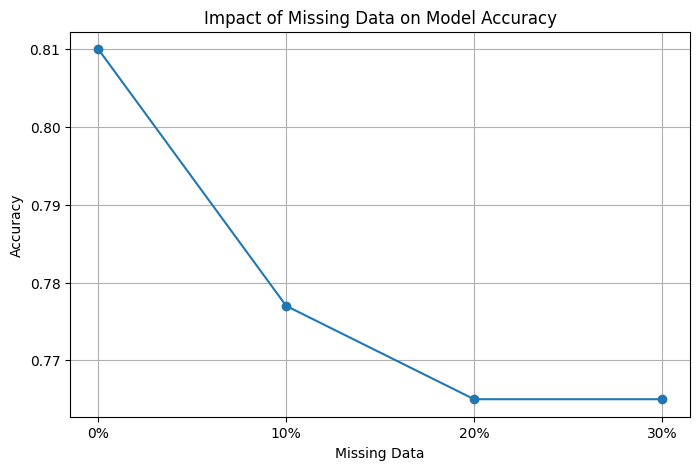

In [13]:
plt.figure(figsize=(8,5))

plt.plot( comparison["Missing Data"],comparison["Accuracy"],marker="o")

plt.xlabel("Missing Data")
plt.ylabel("Accuracy")
plt.title("Impact of Missing Data on Model Accuracy")

plt.grid(True)

plt.show()

## F1-score Comparison

The following graph compares the F1-score obtained under different levels of missing data.

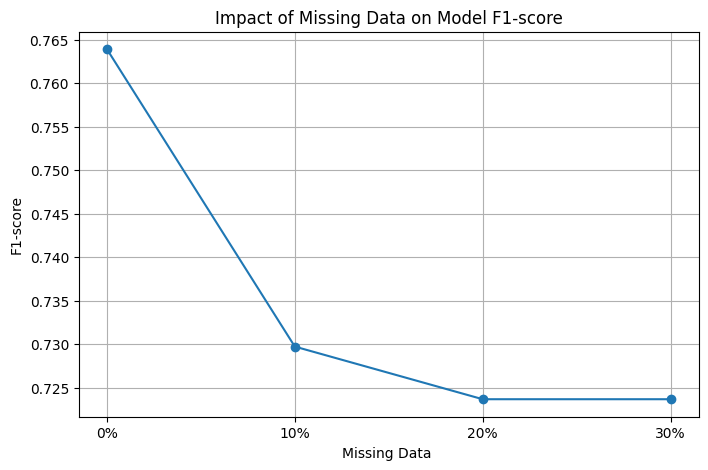

In [14]:
comparison = pd.DataFrame(results)
comparison = comparison.set_index("Missing Data")

plt.figure(figsize=(8,5))

plt.plot(comparison.index,comparison["F1-score"], marker="o")

plt.xlabel("Missing Data ")
plt.ylabel("F1-score")
plt.title("Impact of Missing Data on Model F1-score")

plt.grid(True)

plt.show()